v:  thetao
v:  so
v:  zos
v:  uo
v:  vo


/tmp/ipykernel_1336695/4146777981.py:54: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[i].set_ylim([true_pdf.min(), true_pdf.max()])


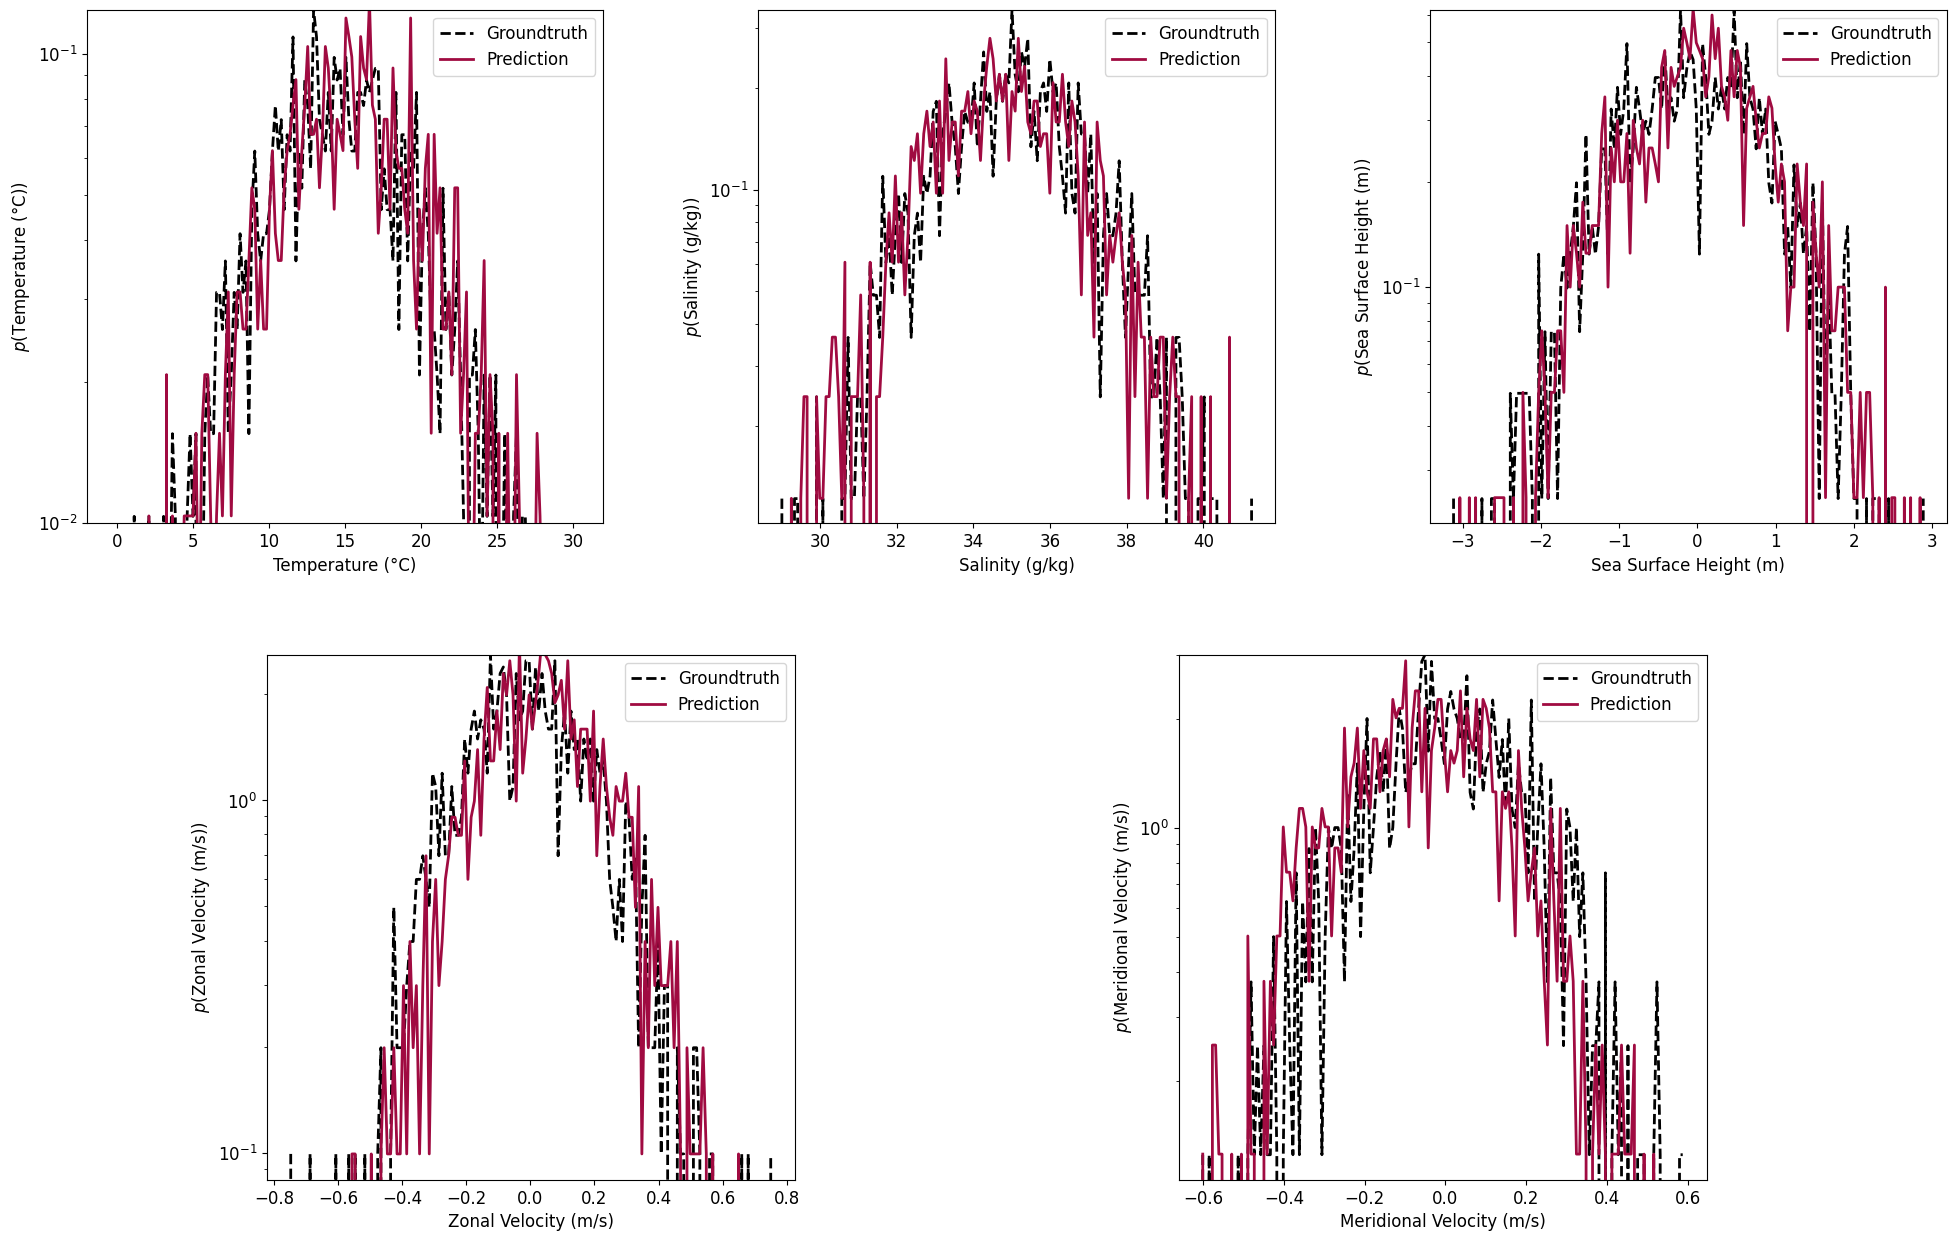

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Variable names for plotting (dummy variables)
var_list = {'thetao': 'Temperature (°C)', 'so': 'Salinity (g/kg)', 'zos': 'Sea Surface Height (m)', 
            'uo': 'Zonal Velocity (m/s)', 'vo': 'Meridional Velocity (m/s)'}

# Create dummy data for groundtruth and predictions
np.random.seed(0)
ds_groundtruth = {
    'thetao': np.random.normal(15, 5, 1000),
    'so': np.random.normal(35, 2, 1000),
    'zos': np.random.normal(0, 1, 1000),
    'uo': np.random.normal(0, 0.2, 1000),
    'vo': np.random.normal(0, 0.2, 1000)
}

ds_prediction = {
    'thetao': np.random.normal(15.5, 5, 1000),
    'so': np.random.normal(34.8, 2, 1000),
    'zos': np.random.normal(0.1, 1, 1000),
    'uo': np.random.normal(0.05, 0.2, 1000),
    'vo': np.random.normal(-0.05, 0.2, 1000)
}

# Create a figure using GridSpec with specific row heights for the top and bottom rows
fig = plt.figure(figsize=(24, 15))
plt.rcParams.update({'font.size': 12})

# Create a GridSpec with 2 rows and 3 columns, giving more height to the top row
gs = fig.add_gridspec(2, 3, height_ratios=[2, 1], hspace=1., wspace=0.3)

# Top row: 3 plots
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Bottom row: using manual positioning with add_axes to place plots between indices 1, 0.5 and 1, 2.5
# Normalized coordinates for custom placement
axs += [fig.add_axes([0.2, 0.1, 0.22, 0.35]), fig.add_axes([0.58, 0.1, 0.22, 0.35])]

# Plot PDFs
for i, v in enumerate(['thetao', 'so', 'zos', 'uo', 'vo']):
    print("v: ", v)
    min_val, max_val = ds_groundtruth[v].min(), ds_groundtruth[v].max()
    true_pdf, bins_true = np.histogram(ds_groundtruth[v], bins=150, density=True, range=(min_val, max_val))
    pdf_net, bins_net = np.histogram(ds_prediction[v], bins=bins_true, density=True, range=(min_val, max_val))

    axs[i].semilogy(bins_true[:-1], true_pdf, label="Groundtruth", color='k', lw=2, ls='--')
    axs[i].semilogy(bins_net[:-1], pdf_net, label="Prediction", color='#A00B41', lw=2)
    axs[i].legend()
    axs[i].set_xlabel(var_list[v])
    axs[i].set_ylabel(r"${p(}$" + var_list[v].split(" $")[0] + "${)}$")

    if v != 'thetao':
        axs[i].set_ylim([true_pdf.min(), true_pdf.max()])
    else:
        axs[i].set_ylim([0.01, true_pdf.max()])
        axs[i].set_xlim([-2, 32])

# Turn off the left-most plot in the bottom row (since it's empty space)
fig.add_subplot(gs[1, 0]).axis("off")

# Save or show the figure
# plt.show()
plt.savefig("composite_pdf.png", bbox_inches='tight')
